<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_4_5_MLR_Ames_Part5_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames Iowa: Part 5
## Tree-Based Methods

**Author:** Brad Sheese

In Parts 1-4, we mostly focussed on Linear Models. (There was a brief foray into capturing non-linear patterns using polynomial features.)  

In this notebook we will explore Tree-Based Models (Decision Trees, Random Forests, and Gradient Boosting) which learn by asking a series of Yes/No questions to split the data, allowing them to capture complex, non-linear patterns automatically.

**Data Source:** http://jse.amstat.org/v19n3/decock/AmesHousing.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download the cleaning module from GitHub
import urllib.request
module_url = "https://raw.githubusercontent.com/bsheese/cs377/main/17_regression_crossval/ames_cleaning.py"
urllib.request.urlretrieve(module_url, "ames_cleaning.py")
from ames_cleaning import load_and_clean_ames

# Load and clean the Ames dataset (no one-hot encoding - trees handle categoricals)
df = load_and_clean_ames(one_hot_encode=False)
print(f"DataFrame shape: {df.shape}")


Final dataframe shape: (2925, 39)


In [2]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['SalePrice'])
y = df['SalePrice'].map(np.log)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Setup complete. Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Setup complete. Train shape: (2340, 38), Test shape: (585, 38)


## Introduction to Tree-Based Methods

 From [wikipedia](https://en.wikipedia.org/wiki/Decision_tree_learning):

> Decision tree learning is a supervised learning approach used in statistics, data mining and machine learning. In this formalism, a classification or regression decision tree is used as a predictive model to draw conclusions about a set of observations.

> Tree models where the target variable can take a discrete set of values are called classification trees; in these tree structures, leaves represent class labels and branches represent conjunctions of features that lead to those class labels. Decision trees where the target variable can take continuous values (typically real numbers) are called regression trees.

> Decision trees are among the most popular machine learning algorithms given their intelligibility and simplicity.

> In decision analysis, a decision tree can be used to visually and explicitly represent decisions and decision making. In data mining, a decision tree describes data (but the resulting classification tree can be an input for decision making).


We are currently implementing regression trees. We will cover classification decision trees when we get to the next section on calssification.

In comparison to our previous approaches to the Ames data, regression trees will make it easy to look for non-linear and interactive predictors

For example:
*   Diminishing Returns: Increasing `Garage Area` from 0 to 400 sq ft adds a lot of value. Increasing it from 1000 to 1400 adds much less.
*   Threshold Effects: Houses built *after* a certain year might command a specific premium due to building codes or styles.
*   Interactions: `Overall Qual` might matter more in certain neighborhoods than others.

Trees handle these scenarios automatically by splitting the data into subsets. You will get a better sense of this after we build a few trees.

## Basic Logic of a Regression Tree

Think of a Decision Tree like a game of "20 Questions." The model tries to predict the price by asking a series of binary questions:
1.  "Is the House larger than 2,000 sq ft?" (Yes/No)
2.  "Is the Overall Quality greater than 7?" (Yes/No)
3.  "Does it have a finished basement?" (Yes/No)

It keeps splitting the data into smaller and smaller buckets until it makes a prediction (the average price of the houses in that bucket). Notice that the model is taking the continuous variables and splitting them at some point to create the yes/no decision.

In the language of machine learning, each point where the model asks one of these questions is called a node (or decision node). The "yes" and "no" answers form branches that lead to the next question. When the model stops asking questions and the data reaches one of those final, smaller buckets to get its prediction, that endpoint is called a leaf (or leaf node). You can picture the data flowing down through a branching path of question nodes until it finally settles on a predicted price at a leaf.



## The Basic Problem with Trees
If we don't stop it, the tree will keep asking questions until it memorizes every single house in the training set. It will have a separate leaf for every unique house. This creates a model that scores 100% on the training exam but fails to generalize to any other dataset (overfitting). Let's make some trees, then we will discuss approaches to reducing the overfitting.

In [13]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# 1. Define a list of max_depth values to experiment with
max_depth_values = [3, 5, 7, 9, 11, None]

# 2. Initialize empty lists for results
depths = []
train_r2s = []
test_r2s = []

print("--- Decision Tree Regressor Performance by Max Depth ---")

# 3. Loop through each max_depth value
for depth in max_depth_values:
    # 4a. Instantiate a DecisionTreeRegressor
    dt_regressor = DecisionTreeRegressor(max_depth=depth, random_state=42)

    # 4b. Fit the regressor to the training data
    dt_regressor.fit(X_train, y_train)

    # 4c. Calculate the R² score on the training data
    train_r2 = dt_regressor.score(X_train, y_train)
    train_r2s.append(train_r2)

    # 4d. Calculate the R² score on the testing data
    test_r2 = dt_regressor.score(X_test, y_test)
    test_r2s.append(test_r2)

    # 4e. Append the current max_depth value
    depths.append(str(depth) if depth is not None else 'None (Unconstrained)')

    print(f"Max Depth: {str(depth) if depth is not None else 'None (Unconstrained)':<20} | Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")

# 5. Create a Pandas DataFrame from the collected results
dt_results_df = pd.DataFrame({
    'Max Depth': depths,
    'Train R2': train_r2s,
    'Test R2': test_r2s
})

print("\nDecision Tree Results DataFrame:")
print(dt_results_df.to_string(index=False, float_format="%.4f"))

--- Decision Tree Regressor Performance by Max Depth ---
Max Depth: 3                    | Train R²: 0.7057 | Test R²: 0.7484
Max Depth: 5                    | Train R²: 0.8268 | Test R²: 0.8171
Max Depth: 7                    | Train R²: 0.9036 | Test R²: 0.8320
Max Depth: 9                    | Train R²: 0.9501 | Test R²: 0.8135
Max Depth: 11                   | Train R²: 0.9786 | Test R²: 0.8128
Max Depth: None (Unconstrained) | Train R²: 1.0000 | Test R²: 0.7863

Decision Tree Results DataFrame:
           Max Depth  Train R2  Test R2
                   3    0.7057   0.7484
                   5    0.8268   0.8171
                   7    0.9036   0.8320
                   9    0.9501   0.8135
                  11    0.9786   0.8128
None (Unconstrained)    1.0000   0.7863


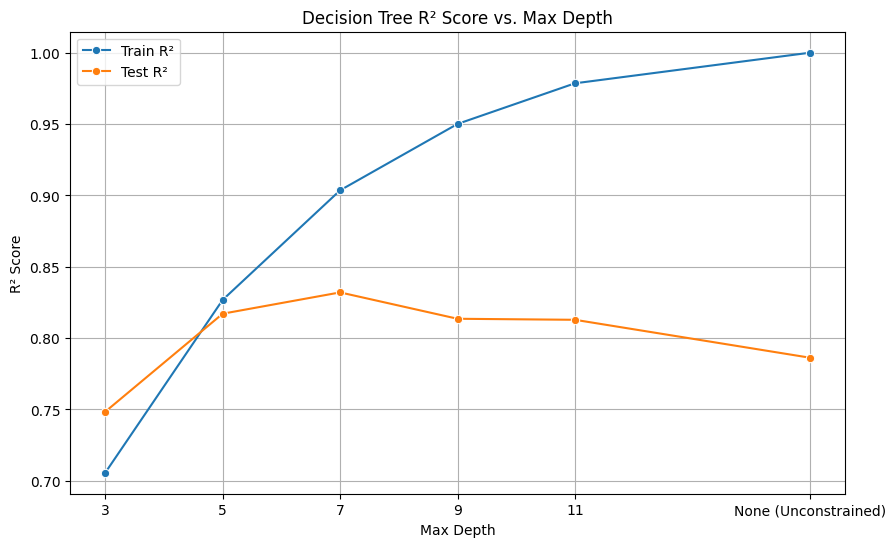

In [14]:
# Prepare data for plotting
plot_df = dt_results_df.copy()
# Convert 'Max Depth' column to numeric for plotting, treating 'None (Unconstrained)' as a large number or specific category
# For visualization, it's often better to represent 'None' distinctly or order it last.
# For a numeric plot, we can assign an arbitrary large number or handle it as a categorical value.
# Let's convert it to a numeric type, assigning a distinct value for 'None' for proper ordering in the plot
plot_df['Max Depth Num'] = plot_df['Max Depth'].replace({'None (Unconstrained)': 15}).astype(float) # Assigning 15 as an example, larger than 11

plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_df, x='Max Depth Num', y='Train R2', marker='o', label='Train R²')
sns.lineplot(data=plot_df, x='Max Depth Num', y='Test R2', marker='o', label='Test R²')

# Customize x-axis ticks to show original labels
x_tick_labels = plot_df['Max Depth'].tolist()
x_tick_positions = plot_df['Max Depth Num'].tolist()
plt.xticks(ticks=x_tick_positions, labels=x_tick_labels)

plt.title('Decision Tree R² Score vs. Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend()
plt.show()

Note that after depth 5, the training set fit continues to improve but the test set does not. These models are increasingly overfit until we reach max depth (depth = None in our code) where the training set if perfectly memorized, but the text set is only at 79%.

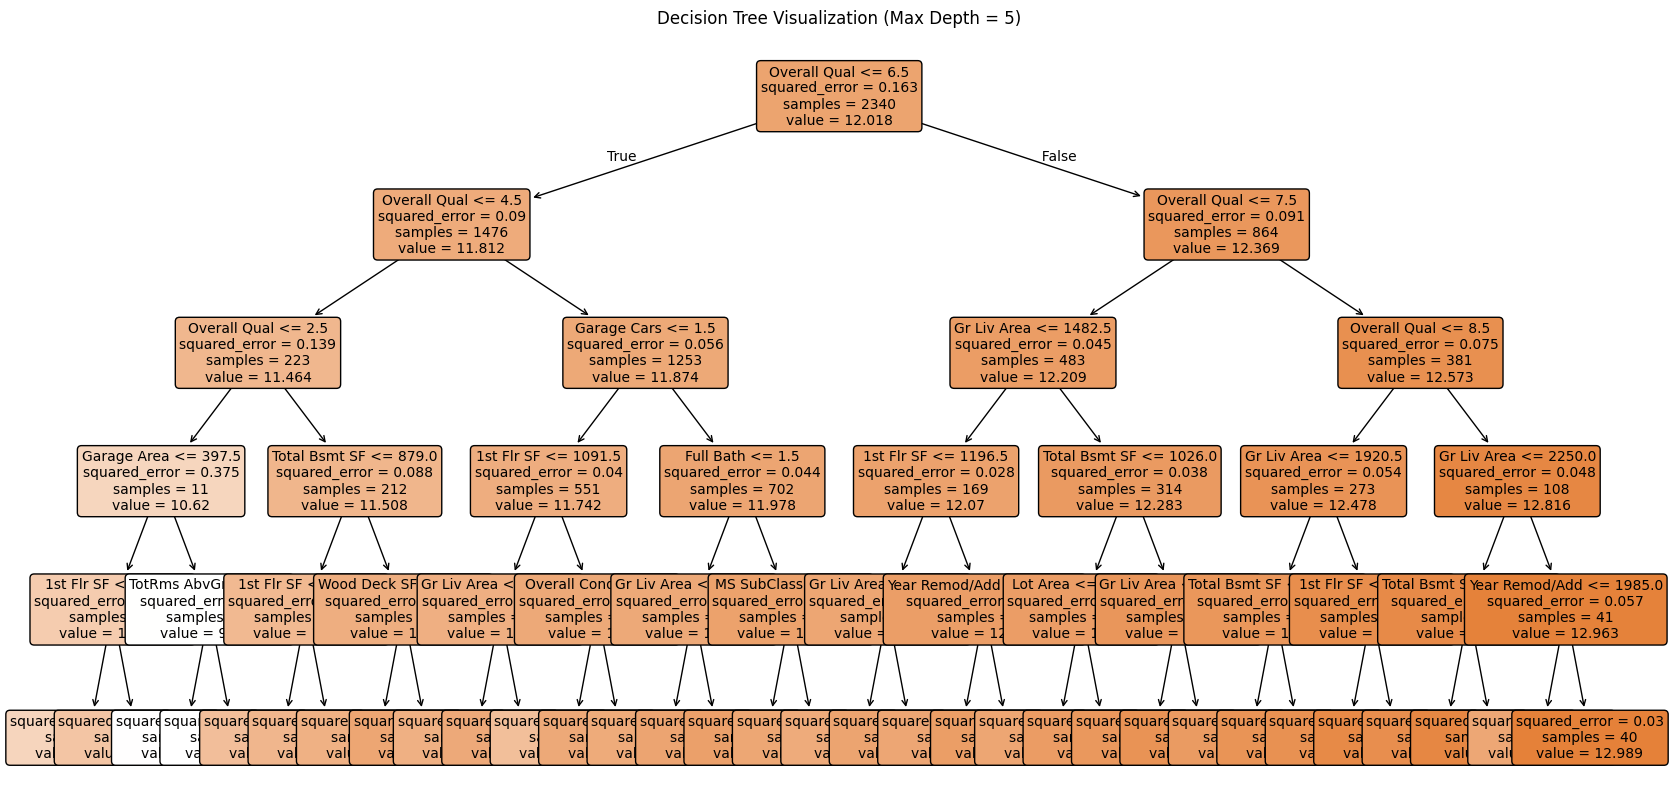

In [16]:
# visualize our depth 5 tree

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Instantiate a DecisionTreeRegressor with max_depth=5 and random_state=42
dt_depth5 = DecisionTreeRegressor(max_depth=5, random_state=42)

# Fit the model using X_train and y_train
dt_depth5.fit(X_train, y_train)

# Use plt.figure to set a large figure size to ensure the tree is legible
plt.figure(figsize=(20, 10))

# Call plot_tree passing the fitted model
plot_tree(dt_depth5,
          feature_names=X_train.columns,
          filled=True,
          rounded=True,
          fontsize=10)

# Display the plot
plt.title('Decision Tree Visualization (Max Depth = 5)')
plt.show()

## Random Forests: Ensemble Learning via Bagging and Parallelization

While a single decision tree is highly interpretable, it typically suffers from "high variance"—meaning it is highly sensitive to the specific data it was trained on and prone to overfitting. If a single tree is unstable and unpredictable, what is the solution? In a word: consensus.

A Random Forest tackles this problem through ensemble learning, a process that builds hundreds (or thousands) of independent decision trees and aggregates their predictions. By tapping into the "wisdom of the crowd," the model averages out individual errors. To ensure this crowd is genuinely diverse, the Random Forest relies on two key mechanisms:

1. Bootstrap Aggregating (Bagging)
If every tree were trained on the exact same dataset, they would all produce nearly identical predictions. To prevent this, each tree is trained on a unique, random subset of the data. This is achieved through a statistical technique called bootstrapping (drawing samples from the dataset with replacement). Because some data points are chosen multiple times while others are left out entirely, each tree develops a slightly different perspective on the problem.

2. Feature Randomness (Decorrelating the Trees)
If we only randomized the data, a highly dominant feature (like "Square Footage" in housing) would still be chosen as the first split (the root node) by almost every tree. The trees would remain highly correlated. To force true diversity, the algorithm introduces a second layer of randomness: at every single node, the tree is restricted to evaluating only a random subset of the available features. This forces the model to explore secondary patterns and completely decorrelates the trees from one another.

Key Concept: Parallelism and Variance Reduction
Because every tree is generated independently and relies on its own randomized data and features, they do not need to communicate or learn sequentially. This allows for massive parallelism, meaning you can train all 100 trees at the exact same time across different CPU cores.

From a machine learning perspective, the primary goal of a Random Forest is variance reduction. While individual trees might overfit and generate noisy predictions, averaging their highly diverse, uncorrelated opinions cancels out that noise. The result is a highly stable, robust model that is far more accurate than any of its individual parts.

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def tune_model(model, param_grid, X_train, y_train):
    """
    Generic function to perform GridSearchCV.
    Note: For Trees, scaling is NOT technically required, but we include it in the pipeline
    for consistency with our Part 4 linear models.
    """
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipeline_param_grid = {f'model__{key}': value for key, value in param_grid.items()}

    grid_search = GridSearchCV(
        pipeline, pipeline_param_grid, cv=5, scoring='r2', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best CV R²: {grid_search.best_score_:.4f}")
    return grid_search.best_estimator_

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None], # note that None max depth means there is not limit
    'max_features': [1.0, 'sqrt']
}

print("--- Tuning Random Forest ---")
best_rf = tune_model(RandomForestRegressor(random_state=42), rf_params, X_train, y_train)

--- Tuning Random Forest ---
Best Parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
Best CV R²: 0.8763


## Gradient Boosting: Ensemble Learning via Sequential Refinement

While Random Forests are excellent at creating a stable model, they are fundamentally "blind" to their own mistakes. Because the trees are generated in parallel and isolated from one another, Tree #100 has no mechanism to recognize or correct a specific error—such as grossly underpricing a mansion—made by Tree #1.

Gradient Boosting shifts the ensemble paradigm entirely. Instead of relying on independent models and the "wisdom of the crowd," boosting builds an additive model in a highly coordinated, sequential manner. In this approach, every new tree is explicitly designed to correct the shortcomings of the trees that came before it.

Here is how the sequential learning process works:
1.  Initial Prediction: The model begins with a very basic, naive prediction (often just the average target value of the dataset).
2.  Calculating Residuals: It evaluates its own performance by calculating the residuals (i.e., the errors).
3.  Targeting the Errors: The next decision tree is trained not* to predict the actual target variable (like the house price), but specifically to predict those residuals.
4.  Updating the Ensemble: The new tree's predictions are added to the running total, nudging the model closer to the true values. The model calculates the new, smaller residuals, and the cycle repeats.

### Key Concept: Sequential Learning and Bias Reduction
If Random Forests use deep, complex trees to reduce variance, Gradient Boosting takes the opposite approach: it uses "weak learners" to reduce bias. These weak learners are typically very shallow trees (sometimes just a single split, or a few nodes) that, on their own, underfit the data. However, by stringing hundreds of them together sequentially, the model continuously chips away at its own inaccuracies.

You can think of this process like a highly specialized assembly line. The first machine cuts out the rough shape of the product, and every subsequent worker on the line focuses specifically on sanding down the exact rough edges (the errors) left by the person before them, culminating in a highly precise final product.

*Note on Implementation:* In the code below, we use `HistGradientBoostingRegressor`. This is Scikit-Learn's modern, highly optimized implementation of gradient boosting. It speeds up the algorithm significantly by grouping continuous data into discrete "bins" (histograms) before making splits, making it incredibly fast and efficient even on large datasets.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Split the data into training and testing sets
# We hold out 20% of the houses to evaluate how well the model generalizes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the Gradient Boosting Regressor
# - max_iter: The number of sequential trees the model will build.
# - learning_rate: Scales the contribution of each tree. A smaller rate requires
#   more trees (max_iter) but often leads to a more robust, generalized model.
hgb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.1,
    random_state=42
)

# 3. Train the model
# This is where the sequential assembly line happens. It starts with a base prediction,
# calculates the residuals, and builds trees to specifically target those errors.
hgb_model.fit(X_train, y_train)

# 4. Generate predictions on the unseen test data
y_pred = hgb_model.predict(X_test)

# 5. Evaluate the model's performance
# Root Mean Squared Error (RMSE) tells us how far off our price predictions are in actual dollars.
# R-squared (R2) tells us the percentage of the variance in house prices our model explains.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"HistGradientBoosting Performance:")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R²): {r2:.4f}")

HistGradientBoosting Performance:
Root Mean Squared Error (RMSE): $0.11
R-squared (R²): 0.9359


What makes `HistGradientBoostingRegressor` special in this case?

Beyond its speed, one of the major advantages of this specific algorithm is that it natively handles missing data (NaNs). Unlike older implementations or basic Random Forests that require you to impute (fill in) missing values before training, the histogram-based builder simply learns whether sending missing values to the left or right node reduces the error the most. It treats "missingness" as just another highly informative feature.

Let's run it again with the raw Ames data.

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target
X = df_raw.drop(columns=['SalePrice'])
y = df_raw['SalePrice'].map(np.log)

# Convert object columns to 'category' dtype for native support
obj_cols = X.select_dtypes(include=['object']).columns
X[obj_cols] = X[obj_cols].astype('category')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Gradient Boosting Regressor with categorical support
hgb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.1,
    random_state=42,
    categorical_features='from_dtype'
)

# Train the model
hgb_model.fit(X_train, y_train)

# Generate predictions
y_pred = hgb_model.predict(X_test)

# Evaluate performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"HistGradientBoosting Performance (Raw Data with Categories):")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.4f}")
print(f"R-squared (R²): {r2:.4f}")

HistGradientBoosting Performance (Raw Data with Categories):
Root Mean Squared Error (RMSE): $0.1110
R-squared (R²): 0.9334


## XGBoost: eXtreme Gradient Boosting

If standard Gradient Boosting is a specialized assembly line where workers sequentially fix each other's mistakes, XGBoost is a fully automated, mathematically optimized smart-factory.

Originally developed as an independent, external library, XGBoost (eXtreme Gradient Boosting) fundamentally changed the landscape of applied machine learning, famously dominating Kaggle competitions for years. It does not alter the core philosophy of sequential boosting; trees are still built one by one to correct the residuals of the previous trees. However, XGBoost elevates the boosting framework through three major innovations:

1. Formalized Regularization (Preventing Overfitting)

    - Standard gradient boosting models are highly susceptible to overfitting; if left unchecked, they will memorize the training data’s noise. XGBoost solves this by introducing a more sophisticated mathematical objective function. When the model evaluates a potential split (a new node), it calculates not only how much the split reduces the error, but also applies a penalty for structural complexity. It utilizes built-in L1 (Lasso) and L2 (Ridge) regularization on the weights of the leaves. In practical terms, this means the algorithm aggressively shrinks the predictions made by individual leaves and mathematically forces the model to discard weak or overly complex splits (a process known as pruning). The model is forced to balance predictive accuracy with structural simplicity.

2. Systems Engineering and Algorithmic Speed

    - Because boosting is inherently sequential (Tree 2 cannot be built until Tree 1 is finished), it is notoriously difficult to parallelize. XGBoost engineers bypassed this bottleneck by parallelizing the internal construction of the trees. Finding the optimal point to split continuous data requires sorting thousands of values, which is incredibly computationally expensive. XGBoost uses an "approximate greedy algorithm" and parallelized feature sorting to evaluate thousands of potential splits simultaneously across different CPU threads. Coupled with hardware-level optimizations like cache-aware memory access, XGBoost processes massive datasets exponentially faster than traditional boosting methods.

3. Sparsity-Awareness (Native Handling of Missing Data)
    - Real-world data is messy and often contains of missing values (NaNs). In standard pipelines, data scientists must mathematically guess or "impute" these missing values before training. XGBoost treats missing data not as an annoyance, but as valuable information. It uses a sparsity-aware split finding algorithm. At every single decision node, the algorithm tests sending all missing values down the left branch, and then down the right branch. It automatically learns which "default direction" minimizes the most error. If a house is missing its "Garage Quality" score, XGBoost will mathematically determine if the mere absence of that data is a reliable indicator of the house's price.


In [10]:
from xgboost import XGBRegressor

# Define features and target
X = df_raw.drop(columns=['SalePrice'])
y = df_raw['SalePrice'].map(np.log)

# Convert object columns to 'category' dtype for native support
obj_cols = X.select_dtypes(include=['object']).columns
X[obj_cols] = X[obj_cols].astype('category')

# 1. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the XGBoost Regressor with Categorical Support
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,

    enable_categorical=True,  # Tells XGBoost to natively parse Pandas 'category' dtypes
    tree_method='hist',       # Required for categorical support; groups data into fast memory bins

    random_state=42
)

# 3. Train the model
# Now, XGBoost will mathematically evaluate "Neighborhood" and "Zoning" dynamically
# without us needing to create hundreds of One-Hot Encoded columns.
xgb_model.fit(X_train, y_train)

# 4. Generate predictions on the unseen test data
y_pred = xgb_model.predict(X_test)

# 5. Evaluate the model's performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost Performance (with Native Categorical Support):")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R²): {r2:.4f}")

XGBoost Performance (with Native Categorical Support):
Root Mean Squared Error (RMSE): $0.11
R-squared (R²): 0.9341


## Feature Importance

Because complex ensembles like Random Forests and XGBoost build hundreds of deeply layered trees, they are frequently criticized as "black boxes." Unlike a simple linear model, you cannot just look at a mathematical equation to understand how the final prediction was made. However, these algorithms actually keep meticulous internal records of their decision-making processes, which we can extract as Feature Importance.

---

To understand how this works, it helps to contrast it directly with traditional statistics:

**Linear Model (Coefficients)**

In a standard linear regression, you are given a coefficient. This is a direct economic multiplier. A coefficient of 50 on "Square Footage" means exactly: for every 1 additional square foot, the house price increases by $50. It is highly interpretable, but it forces a rigid, linear assumption onto the data.

**Tree Model (Impurity / Error Reduction)**

Tree ensembles do not calculate linear multipliers; they calculate usefulness.
Every single time a tree creates a decision node (e.g., "Is Overall Quality > 7?"), it measures exactly how much that specific split reduced the model's overall prediction error (often referred to as decreasing "impurity" or calculating "information gain").

If a split on "Roof Material" barely improves the model's accuracy, it gets a very low score. If a split on "Neighborhood" suddenly makes the subsequent predictions drastically more accurate, it is awarded a massive score for that split.

Across an ensemble of 200 trees, a feature like "Square Footage" might be used to make thousands of different splits. The algorithm simply tallies up the total error reduction attributed to "Square Footage" across every single tree, and divides it by the total error reduction of all features combined.

---
**Relative Predictive Contribution**

Feature Importance is usually expressed as a percentage or a relative score (summing to 1.0). If "Overall Quality" has a score of 0.40, it means that single feature was responsible for 40% of the model's total learning and error reduction.

It is important to note the fundamental limitation here: Feature Importance tells you **what** the model prioritizes, but it does not tell you **how** the feature affects the price. It will definitively tell you that "Lot Size" is a massive driver of the model's predictions, but unlike a linear coefficient, the importance score alone won't explicitly tell you whether a larger lot increases or decreases the price. It simply tells you that to the algorithm, the information was heavily relied upon to reach its final answer.

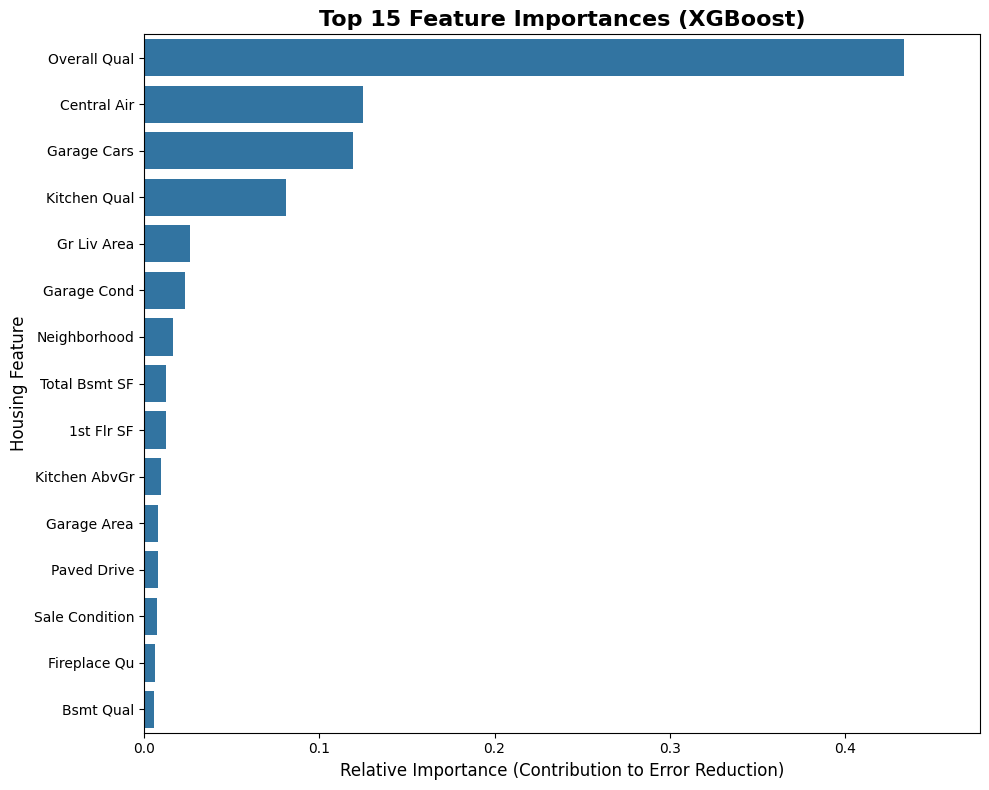

Top 5 Drivers of House Price (According to XGBoost):
- Overall Qual: 43.35%
- Central Air: 12.50%
- Garage Cars: 11.94%
- Kitchen Qual: 8.08%
- Gr Liv Area: 2.64%


In [14]:
# 1. Extract the importance scores
# XGBoost calculates these automatically during training based on how much
# each feature contributed to reducing the model's overall error.
importances = xgb_model.feature_importances_

# 2. Map the scores to their corresponding feature names
# We use X_train.columns to ensure the names line up exactly with the data the model saw.
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 3. Sort the features from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Isolate the Top 15 features (to keep the chart readable)
top_15_features = importance_df.head(15)

# 5. Visualize the results using Seaborn and Matplotlib
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_15_features,
)

# Formatting the plot for readability
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=16, weight='bold')
plt.xlabel('Relative Importance (Contribution to Error Reduction)', fontsize=12)
plt.ylabel('Housing Feature', fontsize=12)
plt.xlim(0, top_15_features['Importance'].max() * 1.1) # Add a little padding to the right
plt.tight_layout()
plt.show()

# Print the exact scores for the top 5 features
print("Top 5 Drivers of House Price (According to XGBoost):")
for index, row in top_15_features.head(5).iterrows():
    # Formatting as a percentage to make the relative importance clearer
    print(f"- {row['Feature']}: {row['Importance'] * 100:.2f}%")

## XGBoost Hyperparameter Tuning: GridSearch and Cross-Validation

While algorithms like XGBoost learn the internal rules (like where to split the square footage) directly from the data, they cannot choose their own external architecture. Decisions like how many trees to build (`n_estimators`), how aggressively to correct previous errors (`learning_rate`), or how deep each tree is allowed to grow (`max_depth`) are called hyperparameters. If you set them poorly, even the best algorithm will overfit the noise or underfit the underlying patterns. Two approaches will help us tune the models hyperparameters:

**Grid Search for Systematic Exploration**

Instead of manually guessing which combination of settings will work best, we define a "grid" of possible values. The Grid Search algorithm systematically tests every single combination of these parameters.

**K-Fold Cross-Validation**

If we test thousands of parameter combinations on a single training set, we run a massive risk: the model might just find a combination that "gets lucky" on that specific slice of data. To prevent this, Grid Search is paired with Cross-Validation. As before, we will rely on k-folds.




In [16]:
from sklearn.model_selection import GridSearchCV

# 1. Define the Hyperparameter Grid
# We are asking the computer to test every combination of these dials.
# (3 learning rates * 3 depths * 3 tree counts = 27 different model architectures)
param_grid = {
    'learning_rate':[0.01, 0.05, 0.1], # How aggressively each tree fixes errors
    'max_depth': [3, 5, 7],             # How many layers deep each tree can grow
    'n_estimators': [100, 300, 500]     # Total number of sequential trees
}

# 2. Initialize the Base Model
# We keep our categorical and hardware optimizations active, but leave the
# hyperparameters blank so GridSearch can fill them in.
base_xgb = XGBRegressor(
    reg_alpha=0.1,
    reg_lambda=1.0,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)

# 3. Setup the GridSearchCV
# - cv=5: Splits the data into 5 folds for cross-validation.
# - scoring: Scikit-Learn tries to *maximize* scores, so for error metrics like RMSE,
#   it uses the negative value (closer to 0 is better).
# - n_jobs=-1: Uses all available CPU cores to speed up this massive calculation.
grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1 # Prints out the progress
)

# 4. Execute the Search (The Heavy Lifting)
# The algorithm is now training and evaluating 27 combinations x 5 folds = 135 models!
print("Starting Grid Search... this may take a moment.")
grid_search.fit(X_train, y_train)

# 5. Extract the Best Results
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_ # This is the final, fully optimized model

print("\nGrid Search Complete!")
print(f"Optimal Hyperparameters Found: {best_params}")

# 6. Final Evaluation on the Unseen Test Set
# We now test our "champion" model on the 20% holdout set we created at the very beginning.
y_pred_optimized = best_model.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_optimized))
final_r2 = r2_score(y_test, y_pred_optimized)

print(f"\nOptimized XGBoost Performance:")
print(f"Root Mean Squared Error (RMSE): ${final_rmse:,.2f}")
print(f"R-squared (R²): {final_r2:.4f}")


Starting Grid Search... this may take a moment.
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Grid Search Complete!
Optimal Hyperparameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}

Optimized XGBoost Performance:
Root Mean Squared Error (RMSE): $0.10
R-squared (R²): 0.9406




### Final Thought
We are getting around ~94% here with no data cleaning. Much less interpretability than OLS regression but faster results.

Think of OLS as one end of the spectrum (very interpretable, very sensitive to data-related problems) and XGBoost as the other (not very interpretable, but not very sensitive to data-related problems.  